# 03 · Basic NLP Techniques

**Objective.** Implement and compare the classical building blocks the use case needs.

**Basic techniques covered (5):** Traditional Text Classification (TF-IDF + Logistic Regression, vs **Naive Bayes** and **Linear SVM**), Sentiment Analysis (VADER vs **traditional ML** vs transformer), Named Entity Recognition (spaCy + rules), POS tagging, and TF-IDF knowledge-base matching (in nb 05).

>  Logic lives in `src/`; these notebooks orchestrate, experiment, visualise and analyse (good-practice separation, ULO6). Run the notebooks in order `01 -> 07` after completing setup in `README.md`.

In [1]:
# --- bootstrap: make `import config` and `from src import ...` work from anywhere ---
import sys, os
from pathlib import Path
p = Path.cwd()
ROOT = next((c for c in [p, *p.parents] if (c/'config.py').exists() and (c/'src').exists()), p)
sys.path.insert(0, str(ROOT)); os.chdir(ROOT)
print('project root:', ROOT)

project root: C:\Users\lenovo\Desktop\ANLP_8420_GROUPC\Assignment3_GroupC\Codes


In [2]:
from src import data_loader
train, val, test = data_loader.load_splits()
import config
X_tr, y_tr = train[config.TEXT_COL], train[config.CATEGORY_COL]
X_te, y_te = test[config.TEXT_COL], test[config.CATEGORY_COL]
len(train), len(test)

(17244, 3696)

## A. Traditional Text Classification

As a baseline model, we use TF-IDF features combined with a Logistic Regression classifier. Both unigrams and bigrams are included so that the model can capture common customer support phrases such as "cancel order" or "track delivery".

Because the dataset contains categories with different numbers of samples, macro-F1 is used as the primary evaluation metric. This metric gives equal importance to each class and provides a more balanced view of performance than overall accuracy alone.

In [3]:
from src.classification import TextClassifier, evaluate
clf = TextClassifier().fit(X_tr, y_tr, kind='logreg')
clf.save()
m = evaluate(clf, X_te, y_te)
print(f"accuracy={m['accuracy']:.4f}  macro_f1={m['macro_f1']:.4f}")
print(m['report_text'])

[clf] saved -> C:\Users\lenovo\Desktop\ANLP_8420_GROUPC\Assignment3_GroupC\Codes\models\tfidf_classifier.joblib
accuracy=0.9978  macro_f1=0.9980
              precision    recall  f1-score   support

     ACCOUNT       1.00      1.00      1.00       817
      CANCEL       0.99      1.00      1.00       142
     CONTACT       1.00      1.00      1.00       300
    DELIVERY       1.00      1.00      1.00       249
    FEEDBACK       1.00      1.00      1.00       300
     INVOICE       1.00      1.00      1.00       274
       ORDER       1.00      1.00      1.00       475
     PAYMENT       1.00      0.99      0.99       300
      REFUND       1.00      1.00      1.00       394
    SHIPPING       1.00      1.00      1.00       295
SUBSCRIPTION       1.00      1.00      1.00       150

    accuracy                           1.00      3696
   macro avg       1.00      1.00      1.00      3696
weighted avg       1.00      1.00      1.00      3696



## Baseline Comparison: Logistic Regression vs Naive Bayes vs Linear SVM

To justify the choice of classifier, three traditional machine learning models were evaluated using the same TF-IDF feature set.

The results show that all three models perform strongly on this dataset, with Linear SVM achieving the highest macro-F1 score. Logistic Regression performs almost identically while remaining simple and computationally efficient. These results indicate that customer support intents are highly separable using traditional NLP features and provide a strong baseline for later LLM-based approaches.

In [4]:
from sklearn.metrics import f1_score, accuracy_score
import pandas as pd
rows = []
for kind in ['logreg', 'nb', 'svm']:
    c = TextClassifier().fit(X_tr, y_tr, kind=kind)
    preds = c.predict_batch(list(X_te))
    rows.append({'model': kind,
                 'accuracy': round(accuracy_score(y_te, preds), 4),
                 'macro_f1': round(f1_score(y_te, preds, average='macro'), 4)})
pd.DataFrame(rows)

,model,accuracy,macro_f1
0,logreg,0.9978,0.9980
1,nb,0.9970,0.9968
2,svm,0.9986,0.9988


The extremely high performance is likely influenced by the structured nature of the Bitext dataset, where many intent categories contain distinctive keywords and patterns. Results on real-world customer service data may be lower due to greater language variation and ambiguity.

C:\Users\lenovo\anaconda3\envs\comp8420\Lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


[eval] saved C:\Users\lenovo\Desktop\ANLP_8420_GROUPC\Assignment3_GroupC\Codes\evaluation\figures\confusion_matrix.png
[eval] saved C:\Users\lenovo\Desktop\ANLP_8420_GROUPC\Assignment3_GroupC\Codes\evaluation\figures\per_class_f1.png


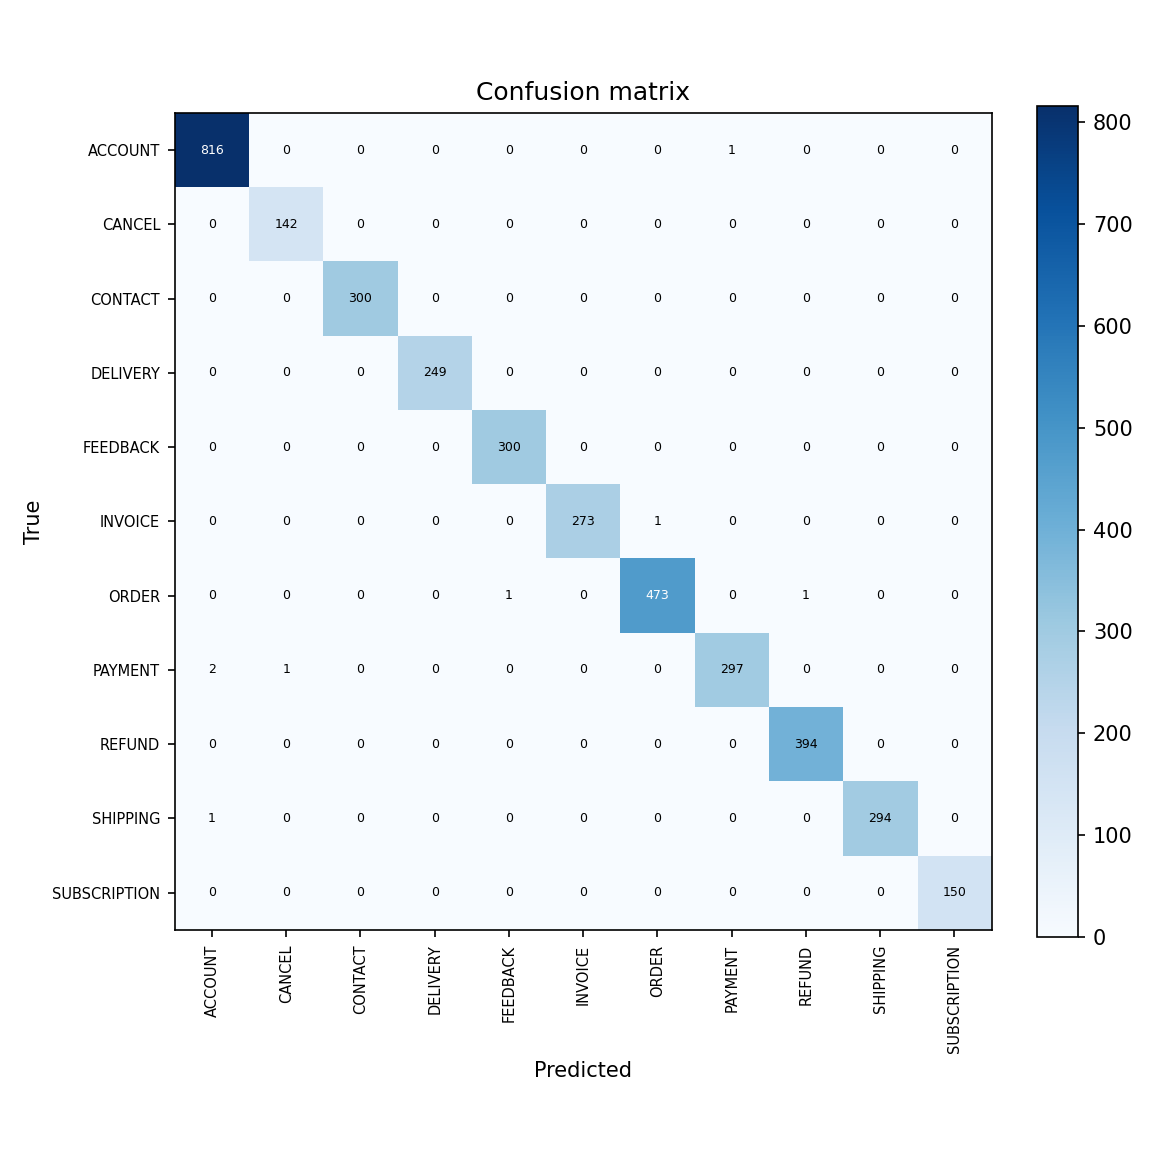

In [5]:
# Confusion matrix + per-class F1 (saved to evaluation/figures/)
from src import evaluation as ev
ev.plot_confusion_matrix(m['confusion_matrix'], m['labels'])
ev.plot_per_class_f1(m['report'])
from IPython.display import Image
Image(str(config.FIG_DIR / 'confusion_matrix.png'))

In [6]:
# Interpretability: top TF-IDF features per class
top = clf.top_features(n=10)
for cat in list(top)[:5]:
    print(f"{cat:>18}: {', '.join(top[cat])}")

           ACCOUNT: account, signup, user, registration, profile, standard, platinum, freemium, pin, pro
            CANCEL: withdrawal, the, termination, cancellation, penalty, fee, fees, charge, penalties, charges
           CONTACT: customer, agent, contact, talk, speak, somebody, person, someone, with, service
          DELIVERY: delivery, shipment, arrive, shipping, methods, options, period, periods, when, soon
          FEEDBACK: feedback, claim, reclamation, complaint, file, lodge, review, leave, make, comment


## Analysis

The confusion matrix shows that most enquiry categories are classified correctly, resulting in a macro-F1 score close to 1.0. Only a small number of misclassifications occur between categories that contain similar language patterns.

This result suggests that many customer support intents can be identified effectively using traditional NLP methods without requiring deep learning models. The TF-IDF representation captures key keywords and phrases associated with each category, making the classifier both accurate and interpretable.

This baseline serves as a useful reference point when evaluating whether more advanced LLM-based solutions provide additional value.

## B. Sentiment Analysis

Customer sentiment is an important signal for prioritising support requests and identifying cases that may require escalation.

Three approaches were explored: VADER as a lexicon-based baseline, a traditional machine learning classifier trained on weak labels, and the option of using transformer-based sentiment models. The examples below demonstrate how different customer messages are assigned positive, negative, or neutral sentiment labels.

In [7]:
from src.sentiment import SentimentAnalyzer, train_ml_sentiment
examples = ["This is unacceptable, I'm furious!",
            'Thanks so much, that was really helpful!',
            'Where is my order?']
vader = SentimentAnalyzer('vader')
for e in examples:
    print(vader.analyze(e)['label'], '|', e)

negative | This is unacceptable, I'm furious!
positive | Thanks so much, that was really helpful!
neutral | Where is my order?


In [8]:
# Train a traditional-ML sentiment model (weak-labelled by VADER - a distillation baseline).
# For a stronger result, pass a small hand-labelled gold set as the 2nd arg.
sample_texts = train[config.TEXT_COL].sample(4000, random_state=42).tolist()
train_ml_sentiment(sample_texts)
ml = SentimentAnalyzer('ml')
for e in examples:
    print(ml.analyze(e)['label'], '|', e)

[sentiment] trained ML model (3 classes) -> C:\Users\lenovo\Desktop\ANLP_8420_GROUPC\Assignment3_GroupC\Codes\models\ml_sentiment.joblib
neutral | This is unacceptable, I'm furious!
negative | Thanks so much, that was really helpful!
neutral | Where is my order?


[eval] saved C:\Users\lenovo\Desktop\ANLP_8420_GROUPC\Assignment3_GroupC\Codes\evaluation\figures\sentiment_by_category.png


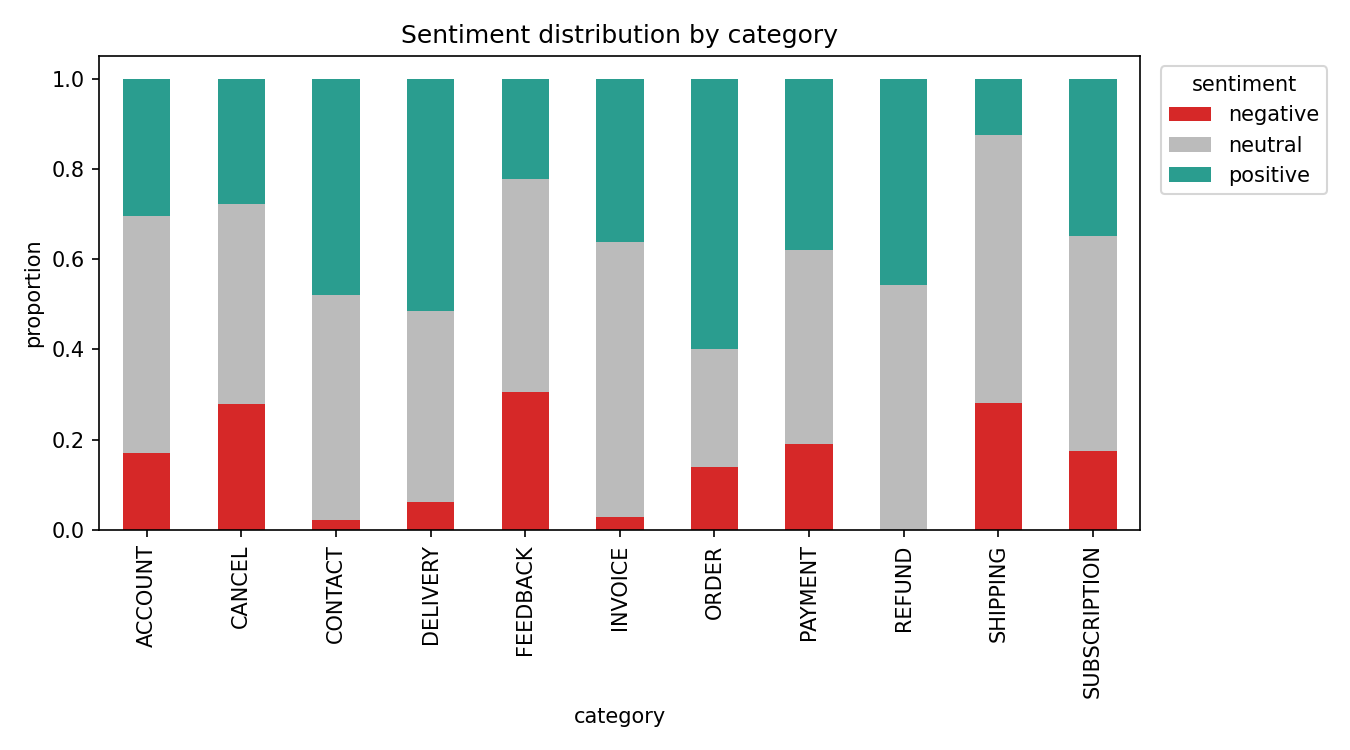

In [9]:
# Sentiment distribution by category (e.g. delivery issues skew negative)
samp = test.sample(min(500, len(test)), random_state=42).copy()
samp['sentiment'] = [vader.analyze(t)['label'] for t in samp[config.TEXT_COL]]
ev.plot_sentiment_by_category(samp, 'sentiment', config.CATEGORY_COL)
Image(str(config.FIG_DIR / 'sentiment_by_category.png'))

## C. Named Entity Recognition
Hybrid: spaCy statistical NER + `EntityRuler`/regex for domain entities (ORDER_NUMBER, INVOICE_NUMBER, …). Extracted facts feed the RAG query and the response template.

In [10]:
from src.ner import EntityExtractor, evaluate_against_placeholders
ner = EntityExtractor()
msg = "Hi, I'm Alex Morgan. My order 48213 of wireless headphones is a delayed delivery."
for e in ner.extract(msg):
    print(f"  {e['label']:<15} {e['text']}")

  PERSON          Alex Morgan
  ORDER_NUMBER    order 48213
  ISSUE_TYPE      delayed delivery


In [11]:
# displaCy render (great screenshot for the report)
from IPython.display import HTML
HTML(ner.render_html(msg))

## NER Evaluation

The named entity recogniser successfully identifies key customer support entities such as customer names, order numbers, and issue descriptions.

To obtain quantitative results, the extracted entities are compared against silver-label entities generated from the Bitext placeholders. Although these labels are automatically derived rather than manually annotated, they provide a useful approximation for evaluating entity extraction performance.

In [12]:
# Entity-level P/R/F1 against Bitext placeholder silver labels
ner_metrics = evaluate_against_placeholders(ner, test, config.TEXT_COL, limit=400)
ner_metrics

{'precision': 0.8493150684931506,
 'recall': 0.8732394366197183,
 'f1': 0.861111111111111,
 'tp': 62,
 'fp': 11,
 'fn': 9}

## D. POS Tagging - understanding query structure
The main **verb** (cancel / refund / track) and **noun chunks** are explainable intent cues that complement the TF-IDF classifier.

In [13]:
from src.pos_tagging import POSTagger
pt = POSTagger()
pt.structure('Please cancel my order and refund the payment to my card.')

{'main_verbs': ['cancel', 'refund'],
 'key_nouns': ['order', 'payment', 'card'],
 'noun_chunks': ['my order', 'the payment', 'my card'],
 'is_question': False,
 'is_imperative': False}

In [14]:
# Corpus-level POS distribution
import matplotlib.pyplot as plt
dist = pt.pos_distribution(test[config.TEXT_COL].head(300).tolist())
labels, vals = zip(*dist.most_common(12))
plt.figure(figsize=(8,3)); plt.bar(labels, vals, color='#6a994e')
plt.title('POS distribution (sample)'); plt.tight_layout(); plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_27712\3309228650.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.title('POS distribution (sample)'); plt.tight_layout(); plt.show()


In [15]:
# Dependency render for one message
from IPython.display import HTML
HTML(pt.render_html('Please cancel my order 48213.'))

## D. POS Tagging – Understanding Query Structure

Part-of-speech tagging provides additional linguistic information about customer enquiries by identifying verbs, nouns, pronouns, and other grammatical components.

The example below highlights how actions such as "cancel" and "refund" are recognised as verbs, while important business objects such as "order" and "payment" are identified as noun phrases. This information helps explain why a message belongs to a particular support category and complements the text classification model.

## Summary

This notebook implemented and evaluated the core NLP components used throughout the customer service system.

The experiments demonstrated:
- Traditional intent classification using TF-IDF and machine learning
- Sentiment analysis for customer prioritisation
- Named entity recognition for extracting customer and order information
- POS tagging for understanding query structure
- Quantitative evaluation using classification metrics and confusion matrices

The results show that traditional NLP methods provide strong performance on the customer support dataset and establish a baseline against which the later LLM and RAG components can be compared.

**Next:** Notebook 04 explores prompting strategies and response generation using foundation language models.